# Lecture 5 companion 2 · EWMA and momentum

Momentum starts with a small idea: **remember a useful direction instead of trusting only the newest measurement**.

We will build that idea in five concrete steps:

1. smooth the same noisy temperature signal with short, medium, and long memory;
2. derive an actual ravine from four regression examples;
3. ask whether feature standardization fixes that ravine;
4. work two momentum updates by hand; and
5. test plain GD and momentum on the exact same loss and gradient budget.

The final cell checks our recurrence against PyTorch's real `momentum_buffer`. No decorative loss surface is used: every optimizer path comes from the displayed four-row dataset.

In [1]:
import random

import matplotlib.pyplot as plt
import numpy as np
import torch

%matplotlib inline

SEED = 12
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

INK = '#23373B'
MUTED = '#6E7F82'
BLUE = '#2B6CB0'
TEAL = '#2C7A7B'
ORANGE = '#EB811B'
PURPLE = '#7952A8'
RED = '#D64550'

np.set_printoptions(precision=7, suppress=True)
plt.rcParams.update({
    'figure.dpi': 125,
    'savefig.dpi': 180,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': .18,
    'font.size': 10.5,
    'legend.frameon': False,
})

## 1. Start with noisy observations—not the formula

The grey dots below are a deterministic, constructed 120-day temperature sequence. A slow seasonal pattern is present, but one day's reading can jump because of noise.

Our question is deliberately simple: **how can we carry one running estimate of the changing trend without storing and re-averaging every past reading?**

Use the companion [EWMA + momentum explorer](https://nipunbatra.github.io/dl-teaching/interactives/ewma-explorer.html) to move through the same observations one day at a time, vary $\beta$, and then inspect the optimizer memory on the computed ravine.

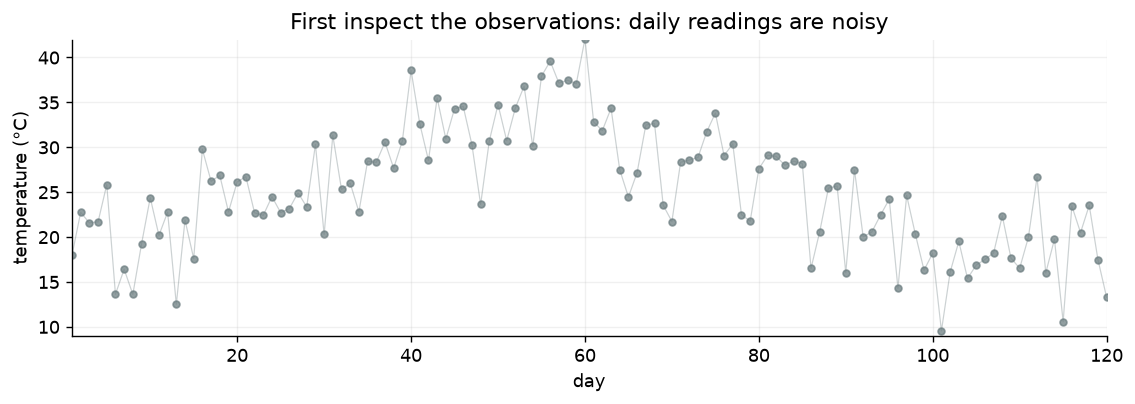

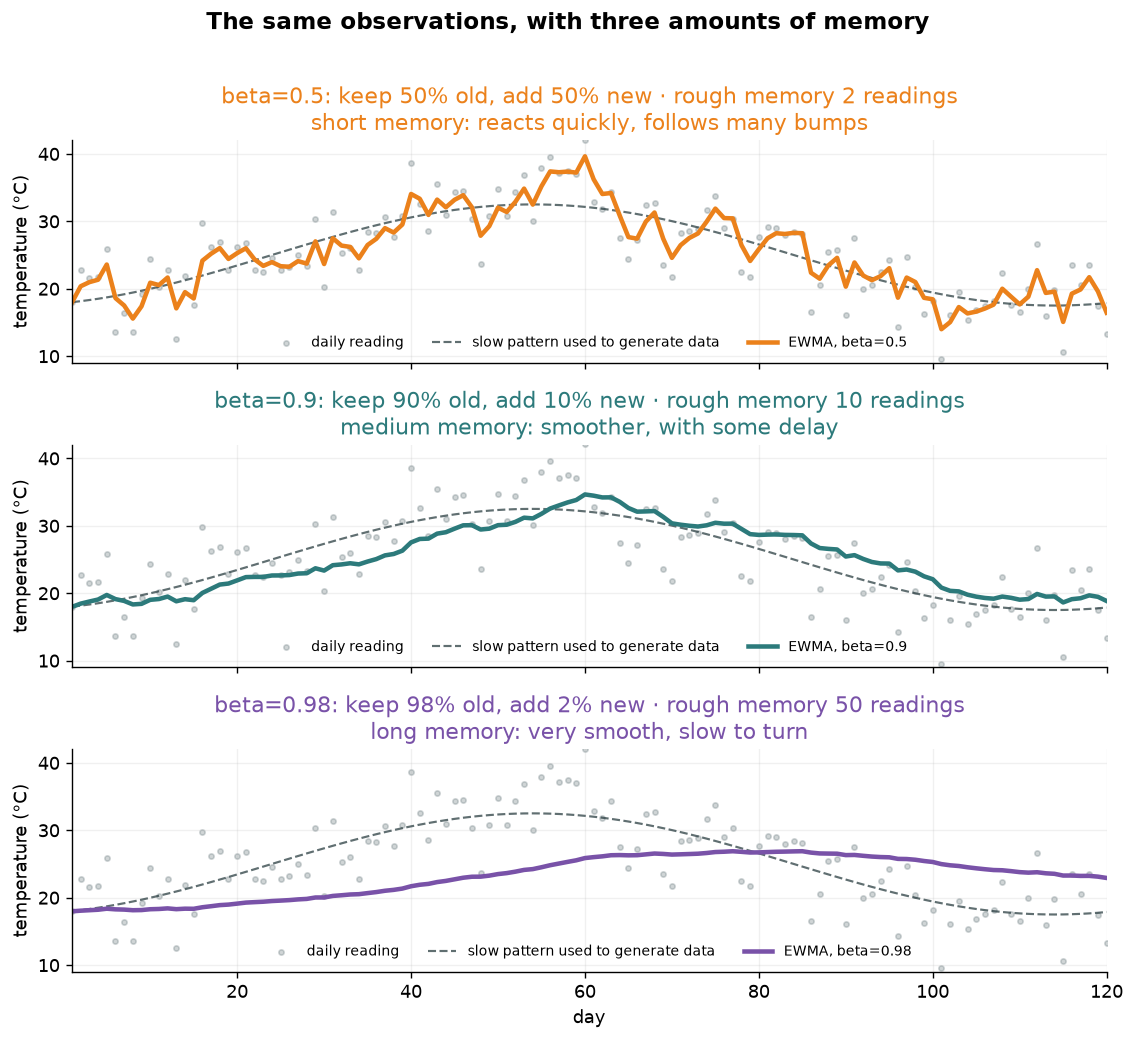

 beta | keep old | add new | rough memory | visible trade-off
 0.50 |     0.50 |    0.50 |            2 | short memory: reacts quickly, follows many bumps
 0.90 |     0.90 |    0.10 |           10 | medium memory: smoother, with some delay
 0.98 |     0.98 |    0.02 |           50 | long memory: very smooth, slow to turn


In [2]:
day = np.arange(1, 121)
temperature_trend = 25.0 + 7.5 * np.sin(2 * np.pi * (day - 24) / 120)
rng = np.random.default_rng(12)
temperature = temperature_trend + rng.normal(0.0, 4.4, size=len(day))

def ewma_from_first(values, beta):
    """Start at the first reading so this plot isolates smoothing and lag."""
    state = float(values[0])
    smoothed = [state]
    for value in values[1:]:
        state = beta * state + (1 - beta) * value
        smoothed.append(state)
    return np.asarray(smoothed)

assert np.allclose(
    temperature[:3],
    [17.96810897, 22.75143955, 21.58044012],
)

fig, ax = plt.subplots(figsize=(9.2, 3.35))
ax.scatter(day, temperature, s=15, color=MUTED, alpha=.75)
ax.plot(day, temperature, color=MUTED, lw=.7, alpha=.35)
ax.set(
    xlim=(1, 120), ylim=(9, 42), xlabel='day', ylabel='temperature (°C)',
    title='First inspect the observations: daily readings are noisy',
)
plt.tight_layout()
plt.show()

beta_specs = [
    (.50, ORANGE, 'short memory: reacts quickly, follows many bumps'),
    (.90, TEAL, 'medium memory: smoother, with some delay'),
    (.98, PURPLE, 'long memory: very smooth, slow to turn'),
]
fig, axes = plt.subplots(3, 1, figsize=(9.2, 8.2), sharex=True, sharey=True)
for ax, (beta, color, interpretation) in zip(axes, beta_specs):
    smoothed = ewma_from_first(temperature, beta)
    ax.scatter(day, temperature, s=9, color=MUTED, alpha=.32, label='daily reading')
    ax.plot(day, temperature_trend, '--', color=INK, lw=1.25,
            alpha=.72, label='slow pattern used to generate data')
    ax.plot(day, smoothed, color=color, lw=2.6,
            label=f'EWMA, beta={beta:g}')
    rough_memory = int(round(1 / (1 - beta)))
    ax.set_title(
        f'beta={beta:g}: keep {100*beta:.0f}% old, add {100*(1-beta):.0f}% new · '
        f'rough memory {rough_memory} readings\n{interpretation}',
        color=color,
    )
    ax.set_ylabel('temperature (°C)')
    ax.legend(ncol=3, fontsize=8.2, loc='lower center')
axes[-1].set_xlabel('day')
axes[0].set_xlim(1, 120)
axes[0].set_ylim(9, 42)
fig.suptitle('The same observations, with three amounts of memory', y=1.01,
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(' beta | keep old | add new | rough memory | visible trade-off')
for beta, _, interpretation in beta_specs:
    print(f' {beta:>4.2f} | {beta:>8.2f} | {1-beta:>7.2f} | '
          f'{1/(1-beta):>12.0f} | {interpretation}')

### EWMA keeps one running memory $m_t$

Here $m_t$ is the **running memory**: the smoothed value after processing observation $x_t$. Keep a fraction $\beta$ of the previous memory and admit a fraction $1-\beta$ of today's observation:

$$m_t=\beta m_{t-1}+(1-\beta)x_t,\qquad 0\leq\beta<1.$$

- The two weights sum to one, so the summary stays on the same scale as the readings.
- Small $\beta$ reacts quickly; large $\beta$ smooths more but lags when the signal turns.
- $1/(1-\beta)$ is a useful rough timescale, not a hard window.

One worked update uses the same convention as the lecture:

$$m_{t-1}=30,\quad x_t=36,\quad\beta=.9
\quad\Longrightarrow\quad
m_t=.9(30)+.1(36)=30.6.$$

### Why ‘exponential’? Unroll the memory

Substitute the same recurrence for the previous memory $m_{t-1}$:

$$\begin{aligned}
m_t
&=\beta[\beta m_{t-2}+(1-\beta)x_{t-1}]+(1-\beta)x_t\\
&=(1-\beta)x_t+(1-\beta)\beta x_{t-1}+\beta^2m_{t-2}.
\end{aligned}$$

Substituting once more gives

$$m_t=(1-\beta)x_t+(1-\beta)\beta x_{t-1}
+(1-\beta)\beta^2x_{t-2}+\beta^3m_{t-3}.$$

Therefore the weight on $x_{t-k}$ is $(1-\beta)\beta^k$: every step into the past contributes one more factor of $\beta$. For $\beta=.9$, the recent-observation weights are

$$.100,\quad .090,\quad .081,\quad .0729,\quad\ldots$$

The weights decay geometrically—by powers of $\beta$. That is the *exponential* in EWMA.

In [3]:
previous_summary = 30.0
today = 36.0
beta = 0.9
updated_summary = beta * previous_summary + (1 - beta) * today

print(f'keep old: {beta:.1f} × {previous_summary:.1f} = {beta*previous_summary:.1f}')
print(f'add new:  {1-beta:.1f} × {today:.1f} = {(1-beta)*today:.1f}')
print(f'updated summary = {updated_summary:.1f} °C')
assert np.isclose(updated_summary, 30.6)

keep old: 0.9 × 30.0 = 27.0
add new:  0.1 × 36.0 = 3.6
updated summary = 30.6 °C


## 2. Derive the ravine from four regression examples

Now return to optimization. Use

$$\hat y_i=\theta_1x_{i1}+\theta_2x_{i2},\qquad
  \boldsymbol\theta^*=(1,-0.5),$$

and generate the targets from the known parameter:

| row $i$ | $x_{i1}$ | $x_{i2}$ | $y_i$ |
|---:|---:|---:|---:|
| 1 | -1 | -10 | 4 |
| 2 | -1 | 10 | -6 |
| 3 | 1 | -10 | 6 |
| 4 | 1 | 10 | -4 |

Start at the actual parameter value $\boldsymbol\theta_0=(-1.4,.35)$. Because $\boldsymbol y=\boldsymbol X\boldsymbol\theta^*$, the residuals are $\boldsymbol X(\boldsymbol\theta-\boldsymbol\theta^*)$. The balanced signs cancel the cross terms, while the second feature's factor of 10 is squared:

$$\frac{\boldsymbol X^\top\boldsymbol X}{N}
  =\begin{bmatrix}1&0\\0&100\end{bmatrix},$$

$$\mathcal L(\boldsymbol\theta)
  =\frac{1}{2N}\|\boldsymbol X\boldsymbol\theta-\boldsymbol y\|^2
  =\frac12(\theta_1-1)^2+50(\theta_2+0.5)^2,$$

$$\nabla\mathcal L(\boldsymbol\theta)
  =(\theta_1-1,\;100(\theta_2+0.5)).$$

This is a computed empirical loss: the ravine comes from the four displayed rows, and the optimum is visibly $\boldsymbol\theta^*=(1,-.5)$.

In [4]:
X = np.array([[-1., -10.], [-1., 10.], [1., -10.], [1., 10.]])
theta_star = np.array([1., -0.5])
y = X @ theta_star
theta0 = np.array([-1.4, 0.35])

def loss_theta(theta):
    return 0.5 * np.mean((X @ theta - y) ** 2)

def grad_theta(theta):
    residual = X @ theta - y
    return X.T @ residual / len(X)

H = X.T @ X / len(X)
prediction0 = X @ theta0
residual0 = prediction0 - y

print(f"{'row':>3} {'x1':>5} {'x2':>5} {'y':>7} {'yhat':>8} {'residual':>10}")
for i, (row, target, pred, residual) in enumerate(
    zip(X, y, prediction0, residual0), start=1
):
    print(f'{i:>3} {row[0]:>5.0f} {row[1]:>5.0f} {target:>7.1f} '
          f'{pred:>8.1f} {residual:>10.1f}')

print('\nX^T X / N =\n', H)
print('theta* =', theta_star)
print('theta0 =', theta0)
print('full gradient at theta0 =', grad_theta(theta0))
print(f'full loss at theta0 = {loss_theta(theta0):.3f}')

assert np.allclose(H, np.diag([1., 100.]))
assert np.allclose(residual0, X @ (theta0 - theta_star))
assert np.allclose(grad_theta(theta0), [-2.4, 85.])
assert np.isclose(loss_theta(theta0), 39.005)

row    x1    x2       y     yhat   residual
  1    -1   -10     4.0     -2.1       -6.1
  2    -1    10    -6.0      4.9       10.9
  3     1   -10     6.0     -4.9      -10.9
  4     1    10    -4.0      2.1        6.1

X^T X / N =
 [[  1.   0.]
 [  0. 100.]]
theta* = [ 1.  -0.5]
theta0 = [-1.4   0.35]
full gradient at theta0 = [-2.4 85. ]
full loss at theta0 = 39.005


### One learning rate must serve two very different coordinates

Plain GD changes the two distances from the optimum independently:

$$\theta_{t+1,1}-1=(1-\eta)(\theta_{t,1}-1),$$

$$\theta_{t+1,2}+0.5=(1-100\eta)(\theta_{t,2}+0.5).$$

The multiplier's **sign** says whether the path crosses the minimum; its **magnitude** says how much distance remains.

| $\eta$ | shallow multiplier | steep multiplier | outcome |
|---:|---:|---:|:---|
| .005 | .995 | .5 | stable, but slow along the valley |
| .019 | .981 | -.9 | contracting zigzag |
| .021 | .979 | -1.1 | expanding zigzag |

At $\eta=.019$, the exact first gradient is $(-2.4,85)$ and the first update in the original parameter space is

$$\boldsymbol\theta_1=(-1.4,.35)-.019(-2.4,85)=(-1.3544,-1.265).$$

The gradient is exact. The difficulty is that one global learning rate must be small enough for the steep direction, so progress along the shallow direction is slow.

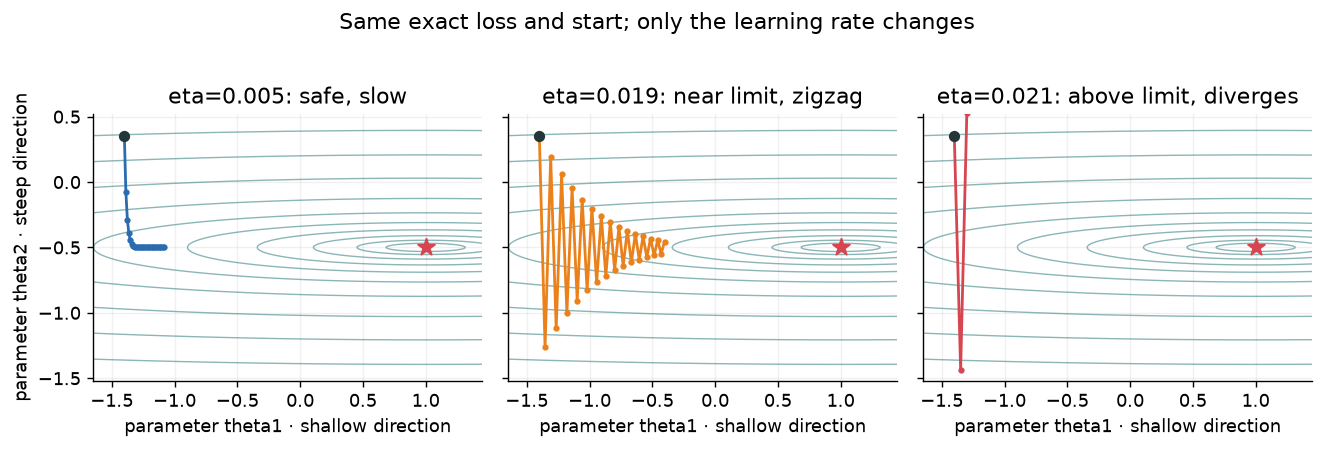

eta=0.005 | steep multiplier= 0.50 | loss after 28 updates=2.1751 | safe, slow
eta=0.019 | steep multiplier=-0.90 | loss after 28 updates=1.0826 | near limit, zigzag
eta=0.021 | steep multiplier=-1.10 | loss after 12 updates=357.5521 | above limit, diverges


In [5]:
def gd_path(eta, steps):
    theta = theta0.copy()
    path = [theta.copy()]
    for _ in range(steps):
        theta = theta - eta * grad_theta(theta)
        path.append(theta.copy())
    return np.asarray(path)

theta1_grid = np.linspace(-1.65, 1.45, 260)
theta2_grid = np.linspace(-1.52, .52, 260)
THETA1, THETA2 = np.meshgrid(theta1_grid, theta2_grid)
loss_grid = 0.5 * (THETA1 - theta_star[0])**2 + 50 * (THETA2 - theta_star[1])**2
contour_levels = [.05, .15, .4, .9, 1.8, 3.5, 7, 14, 25, 40]

rate_specs = [
    (.005, 28, 'safe, slow', BLUE),
    (.019, 28, 'near limit, zigzag', ORANGE),
    (.021, 12, 'above limit, diverges', RED),
]
fig, axes = plt.subplots(1, 3, figsize=(10.8, 3.45), sharex=True, sharey=True)
for ax, (eta, steps, description, color) in zip(axes, rate_specs):
    path = gd_path(eta, steps)
    ax.contour(THETA1, THETA2, loss_grid, levels=contour_levels,
               colors=TEAL, alpha=.55, linewidths=.8)
    visible = np.abs(path[:, 1] - theta_star[1]) <= 1.03
    stop = np.flatnonzero(~visible)
    stop = stop[0] if len(stop) else len(path)
    ax.plot(path[:stop, 0], path[:stop, 1], 'o-', color=color, ms=2.6, lw=1.6)
    ax.scatter(*theta0, color=INK, s=30, zorder=5)
    ax.scatter(*theta_star, marker='*', s=105, color=RED, zorder=5)
    ax.set(
        title=f'eta={eta:.3f}: {description}', xlabel='parameter theta1 · shallow direction',
        xlim=(-1.65, 1.45), ylim=(-1.52, .52),
    )
axes[0].set_ylabel('parameter theta2 · steep direction')
fig.suptitle('Same exact loss and start; only the learning rate changes', y=1.03)
plt.tight_layout()
plt.show()

for eta, steps, description, _ in rate_specs:
    path = gd_path(eta, steps)
    multiplier = 1 - 100 * eta
    print(f'eta={eta:.3f} | steep multiplier={multiplier:>5.2f} | '
          f'loss after {steps:>2} updates={loss_theta(path[-1]):.4f} | {description}')

assert loss_theta(gd_path(.005, 28)[-1]) < loss_theta(theta0)
assert loss_theta(gd_path(.019, 28)[-1]) < loss_theta(theta0)
assert loss_theta(gd_path(.021, 12)[-1]) > loss_theta(theta0)

## 3. Could feature standardization fix this example?

**Yes—for this particular constructed problem.** Define $z_2=x_2/10$. To keep every prediction unchanged, transform the corresponding coefficient as $\phi_2=10\theta_2$:

$$\theta_2x_2=\phi_2z_2.$$

The standardized model's actual parameter vector is

$$\boldsymbol\phi=(\theta_1,10\theta_2),\qquad
  \boldsymbol\phi_0=(-1.4,3.5),\qquad
  \boldsymbol\phi^*=(1,-5).$$

Then

$$\frac{\boldsymbol Z^\top\boldsymbol Z}{N}=I,qquad
  \mathcal L(\boldsymbol\phi)=\frac12(\phi_1-1)^2+\frac12(\phi_2+5)^2.$$

The two directions now have the same curvature, so plain GD can take one reasonably large step size in both.

raw curvature matrix:
 [[  1.   0.]
 [  0. 100.]]
after z2=x2/10:
 [[1. 0.]
 [0. 1.]]
phi0 = [-1.4  3.5] | phi* = [ 1. -5.]
same initial full loss: raw=39.005, standardized=39.005
after 10 updates: raw=6.354289, standardized=0.007069


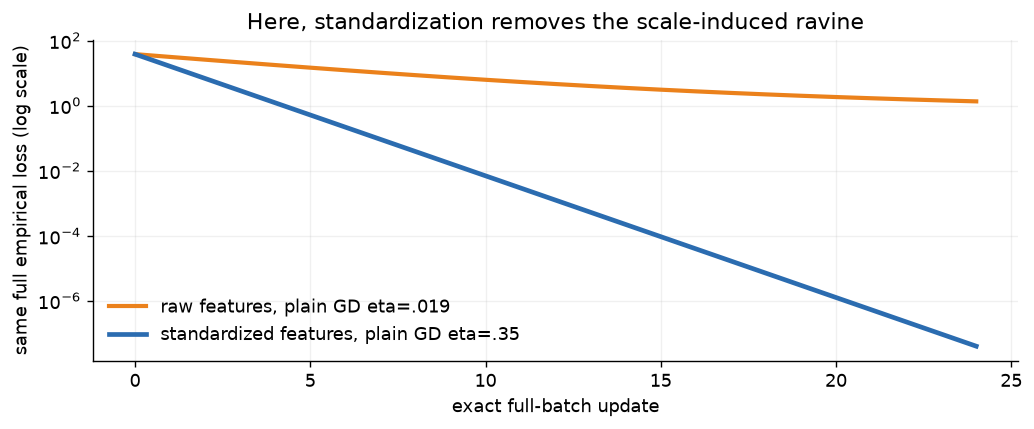

In [6]:
Z = X / np.array([1.0, 10.0])
H_standardized = Z.T @ Z / len(Z)
phi0 = np.array([theta0[0], 10 * theta0[1]])
phi_star = np.array([theta_star[0], 10 * theta_star[1]])

def loss_phi(phi):
    return 0.5 * np.mean((Z @ phi - y) ** 2)

def standardized_gd_path(eta, steps):
    phi = phi0.copy()
    path = [phi.copy()]
    for _ in range(steps):
        phi = phi - eta * (Z.T @ (Z @ phi - y) / len(Z))
        path.append(phi.copy())
    return np.asarray(path)

raw_path = gd_path(.019, 24)
standardized_path = standardized_gd_path(.35, 24)
raw_losses = np.array([loss_theta(theta) for theta in raw_path])
standardized_losses = np.array([loss_phi(phi) for phi in standardized_path])

print('raw curvature matrix:\n', H)
print('after z2=x2/10:\n', H_standardized)
print('phi0 =', phi0, '| phi* =', phi_star)
print(f'same initial full loss: raw={raw_losses[0]:.3f}, standardized={standardized_losses[0]:.3f}')
print(f'after 10 updates: raw={raw_losses[10]:.6f}, standardized={standardized_losses[10]:.6f}')

fig, ax = plt.subplots(figsize=(8.4, 3.55))
ax.semilogy(raw_losses, color=ORANGE, lw=2.4,
            label='raw features, plain GD eta=.019')
ax.semilogy(standardized_losses, color=BLUE, lw=2.7,
            label='standardized features, plain GD eta=.35')
ax.set(
    xlabel='exact full-batch update', ylabel='same full empirical loss (log scale)',
    title='Here, standardization removes the scale-induced ravine',
)
ax.legend()
plt.tight_layout()
plt.show()

assert np.allclose(H_standardized, np.eye(2))
assert np.isclose(raw_losses[0], standardized_losses[0])
assert np.isclose(standardized_losses[10], 0.007069479103462469)
assert standardized_losses[10] < raw_losses[10]

### Does normalization make momentum obsolete? No.

- **Do first:** normalize input features when their scales differ strongly. It completely removes the $100{:}1$ imbalance in this deliberately scale-only example.
- **What remains:** deep networks create correlated, coupled, and changing directions in parameter space; input scaling cannot make all of that geometry uniformly round.
- **Minibatches still fluctuate:** normalization does not make every sampled gradient identical.

**Normalization changes the geometry. Momentum changes how successive gradients are combined. They are complementary.**

## 4. Use the same memory on gradients

Return to the raw-feature ravine and follow plain GD at $\eta=.019$. In the shallow direction,

$$g_{t,1}=\theta_{t,1}-1,\qquad
  |\Delta\theta_{t,1}|=\eta|\theta_{t,1}-1|.$$

As the remaining distance shrinks, the next plain-GD step shrinks too: the first two actual $\theta_1$ moves are $+.0456$ and $+.0447$. Small steps near a true minimum are useful; the difficulty here is that the steep coordinate limits the one global learning rate while $\theta_1$ is still far from its optimum.

Now inspect the recent directions. Along the shallow valley, their signs persist. Across the steep valley, they alternate because the path repeatedly crosses the minimum. Think of each gradient as a push: agreeing pushes can accumulate, while reversed pushes can brake one another. This is an intuition for the recurrence, not a literal force law or a guarantee of a downhill update.

This pattern suggests one memory with two effects:

- let persistent signs reinforce one another and build speed;
- let opposing signs partly cancel and damp the zigzag.

For the comparison below, the GD and normalized-momentum rates are chosen to give the same first displacement. On update 2 the actual $\theta_1$ move is $+.0447$ for GD versus $+.0812$ for momentum; in $\theta_2$ it is $+1.454$ for GD versus $+.162$ for momentum.

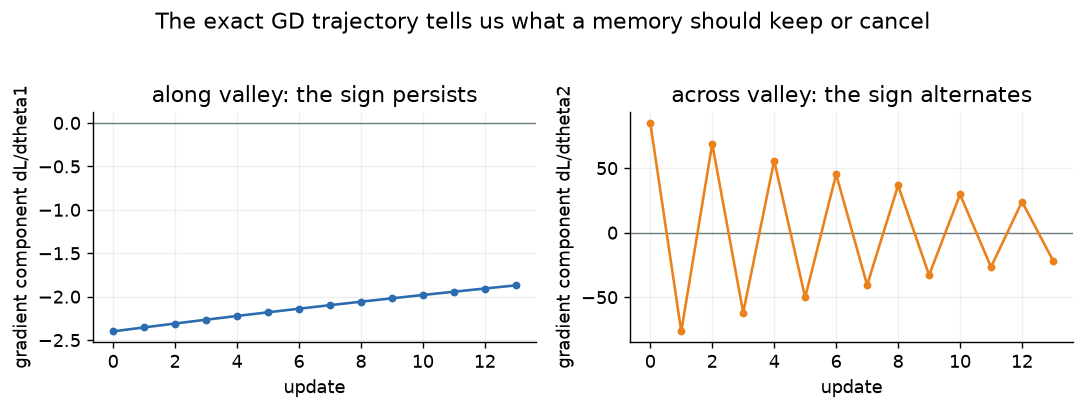

In [7]:
clue_path = gd_path(.019, 14)
clue_gradients = np.array([grad_theta(theta) for theta in clue_path[:-1]])
updates = np.arange(len(clue_gradients))

fig, axes = plt.subplots(1, 2, figsize=(8.8, 3.15), sharex=True)
axes[0].axhline(0, color=MUTED, lw=.8)
axes[0].plot(updates, clue_gradients[:, 0], 'o-', color=BLUE, ms=3.5)
axes[0].set(
    title='along valley: the sign persists', xlabel='update',
    ylabel='gradient component dL/dtheta1',
)
axes[1].axhline(0, color=MUTED, lw=.8)
axes[1].plot(updates, clue_gradients[:, 1], 'o-', color=ORANGE, ms=3.5)
axes[1].set(
    title='across valley: the sign alternates', xlabel='update',
    ylabel='gradient component dL/dtheta2',
)
fig.suptitle('The exact GD trajectory tells us what a memory should keep or cancel', y=1.03)
plt.tight_layout()
plt.show()

assert np.all(clue_gradients[:, 0] < 0)
assert np.all(np.signbit(clue_gradients[1:, 1]) != np.signbit(clue_gradients[:-1, 1]))

### Momentum update 1: there is no history yet

Here $\boldsymbol m_t$ is the optimizer's running memory of earlier gradients. Before any gradient has been observed, there is no history to average and no preferred direction, so we deliberately initialize $\boldsymbol m_0=\boldsymbol0$. This is an initial condition—not a measured gradient and not a learned parameter.

Use a full-batch gradient, $\beta=.8$, and EWMA-form $\eta=.095$. Start from the actual parameters $\boldsymbol\theta_0=(-1.4,.35)$ and perform one complete **measure → remember → move** cycle:

$$\underbrace{\boldsymbol g_0=(-2.4,85)}_{\text{measure}},$$

$$\underbrace{\boldsymbol m_1=.8\boldsymbol m_0+.2\boldsymbol g_0=.2\boldsymbol g_0=(-.48,17)}_{\text{remember}},$$

$$\underbrace{\boldsymbol\theta_1=\boldsymbol\theta_0-.095\boldsymbol m_1=(-1.3544,-1.265)}_{\text{move}}.$$

On update 1, $\beta$ cannot preserve old history because none exists. From update 2 onward, $\boldsymbol m_t$ carries earlier gradients into the new step.

### Momentum update 2: remeasure, then blend

At the new point, keep $\boldsymbol m_1$ and recompute $\boldsymbol g_1=(-2.3544,-76.5)$. The $\theta_1$ components have the same sign and reinforce; the $\theta_2$ components have opposite signs and mostly cancel. The code below prints these two calculations separately before moving to $\boldsymbol\theta_2$.

In [8]:
beta_m = 0.8
eta_m = 0.095

# Update 1: start with no memory.
m0 = np.zeros(2)
g0 = grad_theta(theta0)
m1 = beta_m * m0 + (1 - beta_m) * g0
theta1 = theta0 - eta_m * m1

print('UPDATE 1 · start with no memory')
print('start theta0   =', theta0)
print('initial m0     =', m0, '  # no gradient history yet')
print('measure g0     =', g0)
print('remember m1    =', m1)
print('move theta1    =', theta1)

# Update 2: remeasure at theta1, then blend old and new directions.
g1 = grad_theta(theta1)
old_part = beta_m * m1
new_part = (1 - beta_m) * g1
m2 = old_part + new_part
theta2 = theta1 - eta_m * m2

print('\nUPDATE 2 · remeasure, blend, move')
print('measure g1     =', g1)
print(f'theta1 component: {old_part[0]: .5f} + {new_part[0]: .5f} = {m2[0]: .5f}')
print(f'theta2 component: {old_part[1]: .1f} + {new_part[1]: .1f} = {m2[1]: .1f}')
print('remember m2    =', m2)
print('move theta2    =', theta2)

assert np.allclose(g0, [-2.4, 85.])
assert np.allclose(m1, [-.48, 17.])
assert np.allclose(theta1, [-1.3544, -1.265])
assert np.allclose(g1, [-2.3544, -76.5])
assert np.allclose(m2, [-.85488, -1.7])
assert np.allclose(theta2, [-1.2731864, -1.1035])

UPDATE 1 · start with no memory
start theta0   = [-1.4   0.35]
initial m0     = [0. 0.]   # no gradient history yet
measure g0     = [-2.4 85. ]
remember m1    = [-0.48 17.  ]
move theta1    = [-1.3544 -1.265 ]

UPDATE 2 · remeasure, blend, move
measure g1     = [ -2.3544 -76.5   ]
theta1 component: -0.38400 + -0.47088 = -0.85488
theta2 component:  13.6 + -15.3 = -1.7
remember m2    = [-0.85488 -1.7    ]
move theta2    = [-1.2731864 -1.1035   ]


## 5. Test whether momentum actually helps

The two-step arithmetic explains the mechanism, but it is not yet evidence of better optimization. Compare both methods from the same $\boldsymbol\theta_0$ for **55 exact full-batch gradient evaluations**:

- plain GD: $\eta=.019$;
- normalized momentum: $\beta=.8,\eta=.095$;
- identical first displacement because $(1-\beta)\eta=.019$.

We will inspect the actual objective, distance along the valley, crossings, and total across-valley travel. The two loss curves need not be equally smooth. At the displayed rate, plain GD updates the distances from the optimum as

$$\theta_{t+1,1}-1=.981(\theta_{t,1}-1),$$

$$\theta_{t+1,2}+0.5=-.9(\theta_{t,2}+0.5).$$

Both squared terms therefore shrink every time. Momentum retains direction and can overshoot the steep coordinate, so an individual **full-batch** update can raise the loss. Those rises are optimizer dynamics, not minibatch noise. This is a controlled mechanism example, not a universal optimizer ranking.

55 exact full-batch gradients from the same starting point
method       final loss   |final theta1 - theta1*|   crossings   total across-valley travel
plain GD    0.349461457                  0.835616          55                     16.100851
momentum    0.000136190                  0.002840          29                      9.967197

Plain GD loss decreases on every update: True
Momentum has 25 one-step loss increases: stored motion can overshoot.
Momentum remains below L=.1 from update 26 onward.


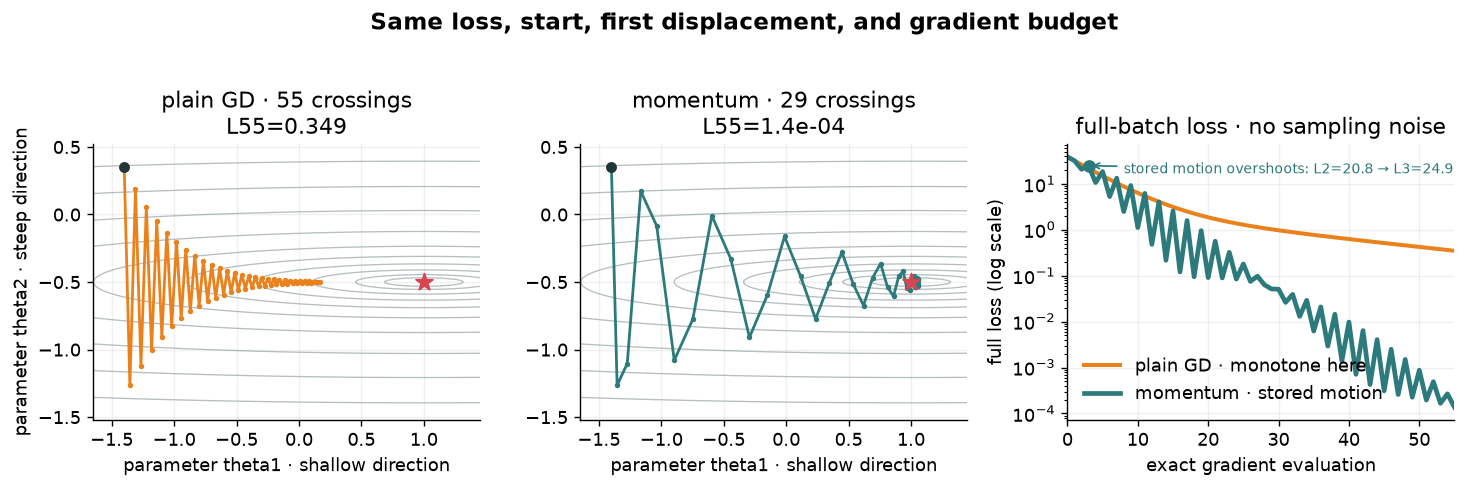

In [9]:
def momentum_trace(eta, beta, steps):
    theta = theta0.copy()
    memory = np.zeros(2)
    path = [theta.copy()]
    gradients = []
    memories = []
    for _ in range(steps):
        gradient = grad_theta(theta)
        memory = beta * memory + (1 - beta) * gradient
        theta = theta - eta * memory
        gradients.append(gradient.copy())
        memories.append(memory.copy())
        path.append(theta.copy())
    return np.asarray(path), np.asarray(gradients), np.asarray(memories)

steps = 55
plain_path = gd_path(.019, steps)
momentum_path, momentum_gradients, momentum_memories = momentum_trace(.095, .8, steps)
plain_loss = np.array([loss_theta(theta) for theta in plain_path])
momentum_loss = np.array([loss_theta(theta) for theta in momentum_path])

def crossings(path):
    steep_error = path[:, 1] - theta_star[1]
    return int(np.count_nonzero(
        np.signbit(steep_error[1:]) != np.signbit(steep_error[:-1])
    ))

def transverse_travel(path):
    return float(np.abs(np.diff(path[:, 1])).sum())

plain_crossings = crossings(plain_path)
momentum_crossings = crossings(momentum_path)
plain_transverse = transverse_travel(plain_path)
momentum_transverse = transverse_travel(momentum_path)
permanently_below = next(
    i for i in range(len(momentum_loss))
    if np.all(momentum_loss[i:] < .1)
)
momentum_rise_updates = np.flatnonzero(np.diff(momentum_loss) > 0) + 1

print('55 exact full-batch gradients from the same starting point')
print('method       final loss   |final theta1 - theta1*|   crossings   total across-valley travel')
print(f'plain GD   {plain_loss[-1]:12.9f}   {abs(plain_path[-1,0]-theta_star[0]):23.6f}'
      f'   {plain_crossings:9d}   {plain_transverse:27.6f}')
print(f'momentum   {momentum_loss[-1]:12.9f}   {abs(momentum_path[-1,0]-theta_star[0]):23.6f}'
      f'   {momentum_crossings:9d}   {momentum_transverse:27.6f}')
print(f'\nPlain GD loss decreases on every update: {np.all(np.diff(plain_loss) < 0)}')
print(f'Momentum has {len(momentum_rise_updates)} one-step loss increases: stored motion can overshoot.')
print(f'Momentum remains below L=.1 from update {permanently_below} onward.')

fig, axes = plt.subplots(1, 3, figsize=(12.2, 3.75))
for ax, path, title, color in [
    (axes[0], plain_path,
     f'plain GD · {plain_crossings} crossings\nL55={plain_loss[-1]:.3f}', ORANGE),
    (axes[1], momentum_path,
     f'momentum · {momentum_crossings} crossings\nL55={momentum_loss[-1]:.1e}', TEAL),
]:
    ax.contour(THETA1, THETA2, loss_grid, levels=contour_levels,
               colors=MUTED, alpha=.5, linewidths=.75)
    ax.plot(path[:, 0], path[:, 1], 'o-', color=color, ms=2.1, lw=1.6)
    ax.scatter(*theta0, color=INK, s=28, zorder=5)
    ax.scatter(*theta_star, marker='*', color=RED, s=105, zorder=5)
    ax.set(
        xlim=(-1.65, 1.45), ylim=(-1.52, .52),
        xlabel='parameter theta1 · shallow direction', title=title,
    )
axes[0].set_ylabel('parameter theta2 · steep direction')
axes[1].set_ylabel('')

update = np.arange(steps + 1)
axes[2].semilogy(update, plain_loss, color=ORANGE, lw=2.3, label='plain GD · monotone here')
axes[2].semilogy(update, momentum_loss, color=TEAL, lw=2.7, label='momentum · stored motion')
overshoot_update = 3
axes[2].scatter(overshoot_update, momentum_loss[overshoot_update],
                color=TEAL, s=40, zorder=5)
axes[2].annotate(
    f'stored motion overshoots: L2={momentum_loss[2]:.1f} → L3={momentum_loss[3]:.1f}',
    xy=(overshoot_update, momentum_loss[overshoot_update]),
    xytext=(8, 17), color=TEAL, fontsize=8.2,
    arrowprops=dict(arrowstyle='->', color=TEAL, lw=1),
)
axes[2].set(
    xlim=(0, 55), xlabel='exact gradient evaluation',
    ylabel='full loss (log scale)', title='full-batch loss · no sampling noise',
)
axes[2].legend()
fig.suptitle('Same loss, start, first displacement, and gradient budget', y=1.03,
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

assert np.allclose(plain_path[1], momentum_path[1])
assert np.isclose(plain_loss[-1], 0.34946145743566004)
assert np.isclose(momentum_loss[-1], 0.00013618968018459663)
assert permanently_below == 26
assert not np.any(plain_loss < .1)
assert np.all(np.diff(plain_loss) < 0)
assert overshoot_update in momentum_rise_updates
assert plain_crossings == 55
assert momentum_crossings == 29
assert np.isclose(plain_transverse, 16.10085146853695)
assert np.isclose(momentum_transverse, 9.967196706485465)
assert abs(momentum_path[-1, 0]-theta_star[0]) < abs(plain_path[-1, 0]-theta_star[0])

## 6. Match the scratch recurrence to PyTorch

Our teaching recurrence stores a normalized EWMA:

$$\boldsymbol m_{t+1}=\beta\boldsymbol m_t+(1-\beta)\boldsymbol g_t,\qquad
  \boldsymbol\theta_{t+1}=\boldsymbol\theta_t-\eta_{\rm EWMA}\boldsymbol m_{t+1}.$$

PyTorch calls its stored state the **momentum buffer** $\boldsymbol v$. For the `SGD(..., momentum=beta)` call below, the states satisfy

$$\boldsymbol m=(1-\beta)\boldsymbol v,\qquad
  \eta_{\rm PT}=(1-\beta)\eta_{\rm EWMA}.$$

Therefore $(1-.8)(.095)=.019$. The next cell compares **every actual parameter point and every stored buffer**, not only the final endpoint.

In [10]:
eta_ewma = .095
beta = .8
steps = 55
numpy_path, _, numpy_memories = momentum_trace(eta_ewma, beta, steps)

Xt = torch.tensor(X, dtype=torch.float64)
yt = torch.tensor(y, dtype=torch.float64)
theta_param = torch.nn.Parameter(torch.tensor(theta0, dtype=torch.float64))
optimizer = torch.optim.SGD(
    [theta_param], lr=eta_ewma * (1 - beta), momentum=beta
)

torch_path = [theta_param.detach().numpy().copy()]
torch_buffers = []
for _ in range(steps):
    optimizer.zero_grad(set_to_none=True)
    objective = 0.5 * ((Xt @ theta_param - yt) ** 2).mean()
    objective.backward()
    optimizer.step()
    torch_path.append(theta_param.detach().numpy().copy())
    torch_buffers.append(
        optimizer.state[theta_param]['momentum_buffer'].detach().numpy().copy()
    )

torch_path = np.asarray(torch_path)
torch_buffers = np.asarray(torch_buffers)
max_path_error = np.max(np.abs(torch_path - numpy_path))
max_state_error = np.max(np.abs((1 - beta) * torch_buffers - numpy_memories))

print('PyTorch learning rate:', optimizer.param_groups[0]['lr'])
print('first momentum_buffer:', torch_buffers[0])
print('final momentum_buffer:', torch_buffers[-1])
print('maximum path difference:', max_path_error)
print('maximum normalized-buffer difference:', max_state_error)

assert np.isclose(optimizer.param_groups[0]['lr'], .019)
assert np.allclose(torch_path, numpy_path, atol=1e-12)
assert np.allclose((1 - beta) * torch_buffers, numpy_memories, atol=1e-12)

PyTorch learning rate: 0.018999999999999996
first momentum_buffer: [-2.4 85. ]
final momentum_buffer: [0.0559939 0.2053993]
maximum path difference: 3.3306690738754696e-16
maximum normalized-buffer difference: 5.329070518200751e-15


### Minimal PyTorch use

```python
optimizer = torch.optim.SGD(model.parameters(), lr=0.019, momentum=0.8)

for xb, yb in loader:
    optimizer.zero_grad(set_to_none=True)
    loss = loss_fn(model(xb), yb)
    loss.backward()
    optimizer.step()
```

The scratch recurrence explains what persists. PyTorch handles parameter groups, devices, dtypes, and state storage.

## Takeaways

1. EWMA's $\beta$ is a memory dial: `.5` reacts, `.9` balances, and `.98` is smooth but slow to turn on the same noisy signal.
2. The four regression rows produce real $100{:}1$ curvature, so an exact gradient can still zigzag under one global learning rate.
3. Standardization completely fixes this deliberately scale-induced ravine, but it does not remove deep-network coupling or minibatch noise. Normalization and momentum are complementary.
4. On the controlled 55-gradient comparison, momentum lowers the loss from `.349461` to `.000136`, stays below $\mathcal L=.1$ after update 26, and reduces total across-valley travel from `16.101` to `9.967`.
5. For $\beta=.8$, normalized $\eta_{\rm EWMA}=.095$ and PyTorch `lr=.019` generate the same parameter path under the stated restrictions.